In [1]:
!pip install focal-loss

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2025-12-23 08:58:58.931974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766480339.117628      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766480339.175427      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766480339.613910      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766480339.613965      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766480339.613972      55 computation_placer.cc:177] computation placer alr

In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
model_name = 'MobileNetV2'
model_name

'MobileNetV2'

In [9]:
preprocess_fn = applications.mobilenet_v2.preprocess_input

In [10]:
def build_data_augmentation(SEED=24520152):
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name='data_augmentation')

In [11]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [12]:
def build_mobilenetv2(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a MobileNetV2 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name='input_layer')

    backbone = applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [13]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_mobilenetv2()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [14]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_classifier(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_5_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('mobilenetv2_1.00_224')
    backbone.trainable = True

    # unfreeze block 13 -> 16
    # unfreeze block 9 -> 16
    # unfreeze block 5 -> 16
    # unfreeze block 1 -> 16
    
    set_trainable = False
    if block == 1:
        set_trainable = True
    for layer in backbone.layers:
        if layer.name == f'block_{block * 4 - 3}_expand':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [16]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_block(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
        block=block,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [17]:
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 5
Found 542 files belonging to 3 classes.


I0000 00:00:1766480353.667276      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


/tmp/ipykernel_55/3387384670.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


...

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/50


I0000 00:00:1766480372.076191     134 service.cc:152] XLA service 0x79a1f0110930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766480372.076255     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766480373.182046     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1766480379.175066     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.5501 - loss: 0.5926
Epoch 1: val_accuracy improved from -inf to 0.84133, saving model to /kaggle/working/MobileNetV2_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 64s 548ms/step - accuracy: 0.5525 - loss: 0.5882 - val_accuracy: 0.8413 - val_loss: 0.1510 - learning_rate: 0.0010
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7493 - loss: 0.2754
Epoch 2: val_accuracy did not improve from 0.84133
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step - accuracy: 0.7495 - loss: 0.2750 - val_accuracy: 0.8339 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 3/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7994 - loss: 0.2093
Epoch 3: val_accuracy improved from 0.84133 to 0.88376, saving model to /kaggle/working/MobileNetV2_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - accuracy: 0.7996 - loss: 0.2091 - val_accuracy: 0.8838 - val_loss: 0.1021 - learning_rate: 0.0010
Epoch 4/50
80/81 ━━━━━━━━━━━━━━━━━━━━

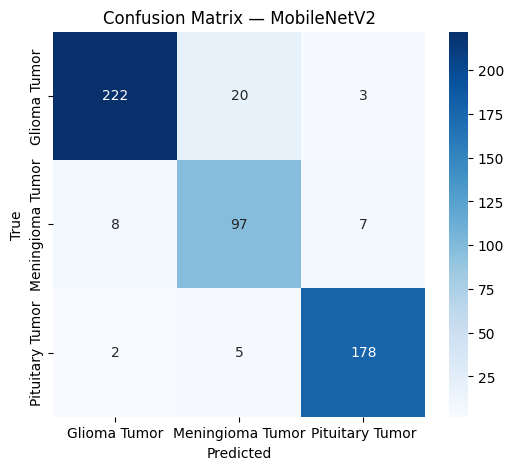

Fold: 1 block 4


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

...

36/81 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - accuracy: 0.7149 - loss: 0.3723

2025-12-23 09:04:33.622551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-23 09:04:33.821932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


56/81 ━━━━━━━━━━━━━━━━━━━━ 12s 514ms/step - accuracy: 0.7225 - loss: 0.3542

2025-12-23 09:04:50.963793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-23 09:04:51.163070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.7316 - loss: 0.3363
Epoch 1: val_accuracy improved from -inf to 0.92620, saving model to /kaggle/working/MobileNetV2_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 594ms/step - accuracy: 0.7323 - loss: 0.3350 - val_accuracy: 0.9262 - val_loss: 0.0709 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8061 - loss: 0.2029
Epoch 2: val_accuracy improved from 0.92620 to 0.92804, saving model to /kaggle/working/MobileNetV2_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8061 - loss: 0.2028 - val_accuracy: 0.9280 - val_loss: 0.0678 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8215 - loss: 0.1551
Epoch 3: val_accuracy improved from 0.92804 to 0.92989, saving model to /kaggle/working/MobileNetV2_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8216 - loss: 0.1551 - val_accuracy: 0.9299 - 

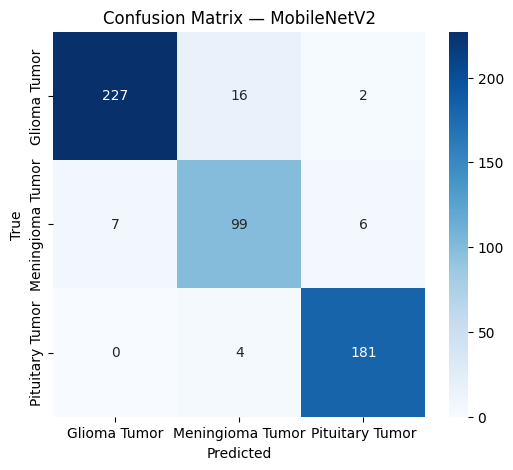

Fold: 1 block 3


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,632,203 (21.49 MB)

 Trainable params: 1,685,187 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,370,376 (12.86 MB)

None
Epoch 1/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8308 - loss: 0.1645
Epoch 1: val_accuracy improved from -inf to 0.92620, saving model to /kaggle/working/MobileNetV2_block_3_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 725ms/step - accuracy: 0.8307 - loss: 0.1646 - val_accuracy: 0.9262 - val_loss: 0.0638 - learning_rate: 1.0000e-05
Epoch 2/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8495 - loss: 0.1484
Epoch 2: val_accuracy did not improve from 0.92620
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.8494 - loss: 0.1486 - val_accuracy: 0.9170 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 3/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8535 - loss: 0.1374
Epoch 3: val_accuracy did not improve from 0.92620
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.8537 - loss: 0.1373 - val_accuracy: 0.9225 - val_loss: 0.0640 - learning_rate: 1.0000e-05
Epoch 4/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8767 - loss: 

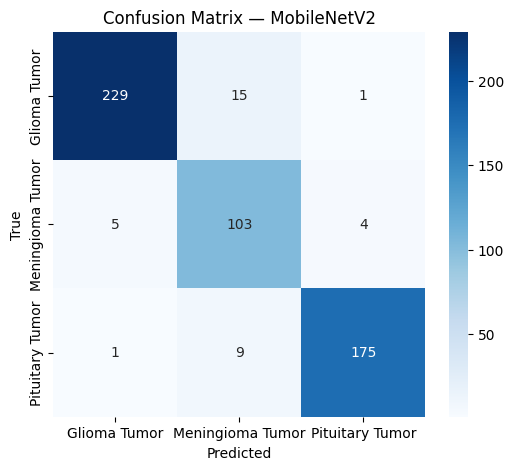

Fold: 1 block 2


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347,083 (24.21 MB)

 Trainable params: 2,042,627 (7.79 MB)

 Non-trainable params: 219,200 (856.25 KB)

 Optimizer params: 4,085,256 (15.58 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.8746 - loss: 0.1224
Epoch 1: val_accuracy improved from -inf to 0.93173, saving model to /kaggle/working/MobileNetV2_block_2_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 109s 908ms/step - accuracy: 0.8746 - loss: 0.1223 - val_accuracy: 0.9317 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8730 - loss: 0.1215
Epoch 2: val_accuracy did not improve from 0.93173
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.8731 - loss: 0.1213 - val_accuracy: 0.9280 - val_loss: 0.0718 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8900 - loss: 0.0949
Epoch 3: val_accuracy improved from 0.93173 to 0.93542, saving model to /kaggle/working/MobileNetV2_block_2_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.8900 - loss: 0.0950 - val_accuracy: 0.9354 - val_loss: 0.0631 - learning_rate: 1.0000e-05
Epoch 4/

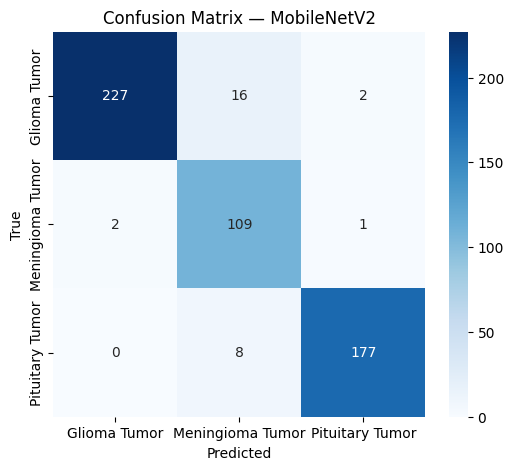

Fold: 1 block 1


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,635,979 (25.31 MB)

 Trainable params: 2,187,075 (8.34 MB)

 Non-trainable params: 74,752 (292.00 KB)

 Optimizer params: 4,374,152 (16.69 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8850 - loss: 0.1153
Epoch 1: val_accuracy improved from -inf to 0.92620, saving model to /kaggle/working/MobileNetV2_block_1_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9028 - loss: 0.0845
Epoch 2: val_accuracy did not improve from 0.92620
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9027 - loss: 0.0845 - val_accuracy: 0.9151 - val_loss: 0.0830 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9135 - loss: 0.0706
Epoch 3: val_accuracy did not improve from 0.92620
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.9134 - loss: 0.0707 - val_accuracy: 0.9133 - val_loss: 0.0798 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9120 - loss: 0.0839
Epoch 4: val_accuracy did not improve from 0.92620

Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
81/81 ━━━━━━━━━━━━━━━━━━

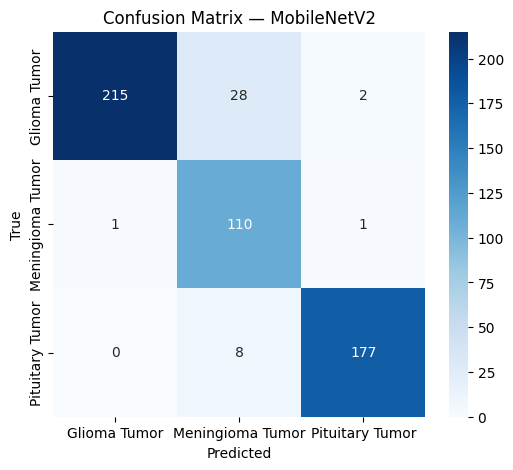

Fold: 2 block 5
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


/tmp/ipykernel_55/3387384670.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = applications.MobileNetV2(


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.5714 - loss: 0.5185
Epoch 1: val_accuracy improved from -inf to 0.78056, saving model to /kaggle/working/MobileNetV2_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 45s 423ms/step - accuracy: 0.5739 - loss: 0.5151 - val_accuracy: 0.7806 - val_loss: 0.2178 - learning_rate: 0.0010
Epoch 2/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7866 - loss: 0.2124
Epoch 2: val_accuracy improved from 0.78056 to 0.78351, saving model to /kaggle/working/MobileNetV2_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.7868 - loss: 0.2124 - val_accuracy: 0.7835 - val_loss: 0.1972 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8051 - loss: 0.1977
Epoch 3: val_accuracy improved from 0.78351 to 0.79971, saving model to /kaggle/working/MobileNetV2_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.8051 - loss: 0.1976 - val_accuracy: 0

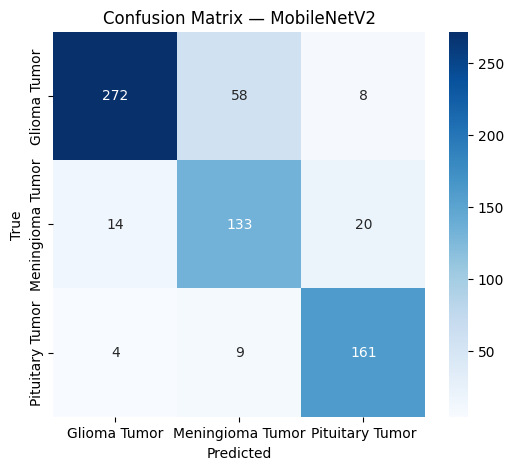

Fold: 2 block 4


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

None
Epoch 1/50
53/76 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - accuracy: 0.6851 - loss: 0.4156

2025-12-23 09:30:01.216781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-23 09:30:01.414756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.7017 - loss: 0.3891
Epoch 1: val_accuracy improved from -inf to 0.82769, saving model to /kaggle/working/MobileNetV2_block_4_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 66s 607ms/step - accuracy: 0.7030 - loss: 0.3871 - val_accuracy: 0.8277 - val_loss: 0.1699 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8110 - loss: 0.1740
Epoch 2: val_accuracy did not improve from 0.82769
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.8111 - loss: 0.1740 - val_accuracy: 0.8218 - val_loss: 0.1764 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8389 - loss: 0.1520
Epoch 3: val_accuracy did not improve from 0.82769
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.8390 - loss: 0.1520 - val_accuracy: 0.8262 - val_loss: 0.1808 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8595 - loss: 0.1343
Epoch 4: 

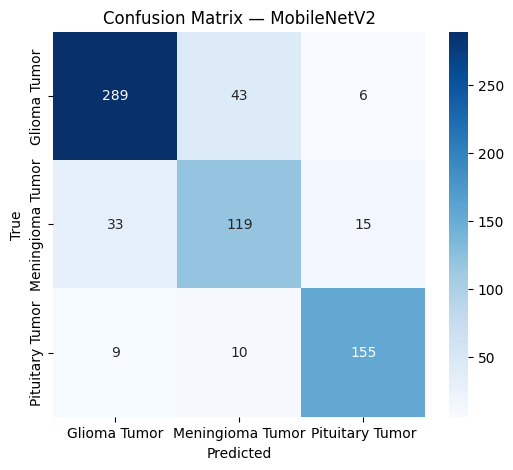

Fold: 2 block 3


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,632,203 (21.49 MB)

 Trainable params: 1,685,187 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,370,376 (12.86 MB)

None
Epoch 1/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.8349 - loss: 0.1813
Epoch 1: val_accuracy improved from -inf to 0.82327, saving model to /kaggle/working/MobileNetV2_block_3_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 85s 754ms/step - accuracy: 0.8351 - loss: 0.1809 - val_accuracy: 0.8233 - val_loss: 0.2027 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8705 - loss: 0.1383
Epoch 2: val_accuracy did not improve from 0.82327
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.8705 - loss: 0.1383 - val_accuracy: 0.8130 - val_loss: 0.2134 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8654 - loss: 0.1311
Epoch 3: val_accuracy did not improve from 0.82327
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.8656 - loss: 0.1310 - val_accuracy: 0.8189 - val_loss: 0.2147 - learning_rate: 1.0000e-05
Epoch 4/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8685 - loss: 

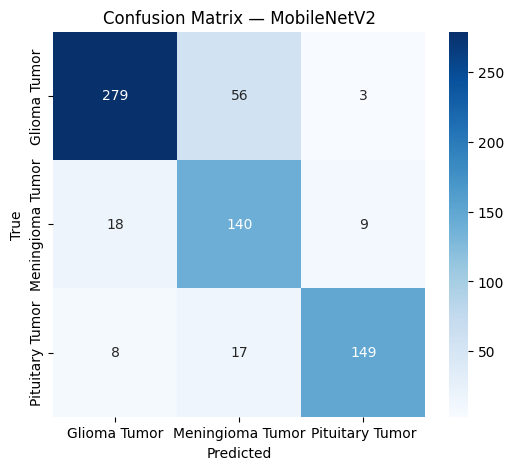

Fold: 2 block 2


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347,083 (24.21 MB)

 Trainable params: 2,042,627 (7.79 MB)

 Non-trainable params: 219,200 (856.25 KB)

 Optimizer params: 4,085,256 (15.58 MB)

None
Epoch 1/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.8653 - loss: 0.1272
Epoch 1: val_accuracy improved from -inf to 0.83947, saving model to /kaggle/working/MobileNetV2_block_2_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 104s 930ms/step - accuracy: 0.8658 - loss: 0.1269 - val_accuracy: 0.8395 - val_loss: 0.2251 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8789 - loss: 0.1135
Epoch 2: val_accuracy did not improve from 0.83947
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.8789 - loss: 0.1135 - val_accuracy: 0.8351 - val_loss: 0.2366 - learning_rate: 1.0000e-05
Epoch 3/50
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8949 - loss: 0.0955
Epoch 3: val_accuracy did not improve from 0.83947
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.8950 - loss: 0.0954 - val_accuracy: 0.8321 - val_loss: 0.2391 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9009 - loss:

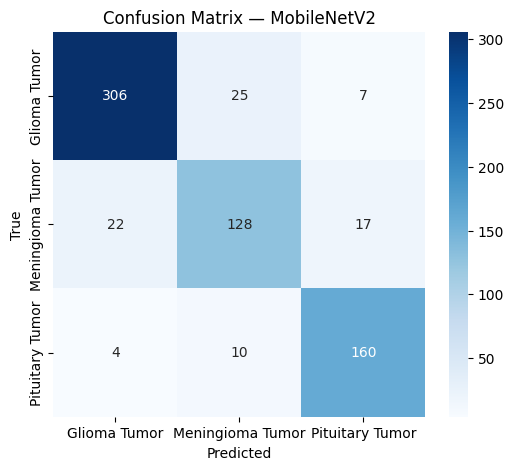

Fold: 2 block 1


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,635,979 (25.31 MB)

 Trainable params: 2,187,075 (8.34 MB)

 Non-trainable params: 74,752 (292.00 KB)

 Optimizer params: 4,374,152 (16.69 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9030 - loss: 0.0918
Epoch 1: val_accuracy improved from -inf to 0.86745, saving model to /kaggle/working/MobileNetV2_block_1_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9030 - loss: 0.0919 - val_accuracy: 0.8675 - val_loss: 0.1401 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9142 - loss: 0.0814
Epoch 2: val_accuracy did not improve from 0.86745
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.9143 - loss: 0.0813 - val_accuracy: 0.8660 - val_loss: 0.1478 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9054 - loss: 0.0953
Epoch 3: val_accuracy did not improve from 0.86745
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.9055 - loss: 0.0951 - val_accuracy: 0.8557 - val_loss: 0.1519 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9064 - loss: 0.086

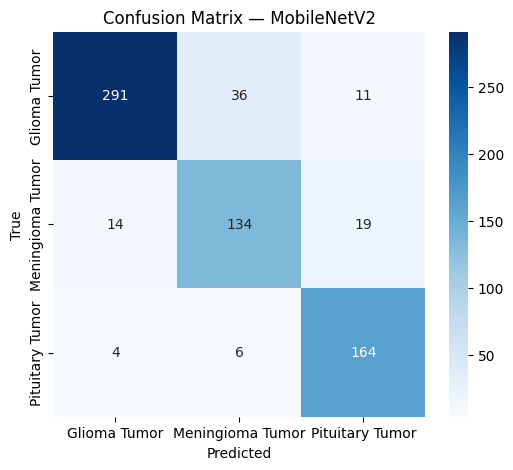

Fold: 3 block 5
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


/tmp/ipykernel_55/3387384670.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = applications.MobileNetV2(


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5777 - loss: 0.5246
Epoch 1: val_accuracy improved from -inf to 0.76224, saving model to /kaggle/working/MobileNetV2_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 405ms/step - accuracy: 0.5789 - loss: 0.5229 - val_accuracy: 0.7622 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7758 - loss: 0.2139
Epoch 2: val_accuracy improved from 0.76224 to 0.80594, saving model to /kaggle/working/MobileNetV2_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.7760 - loss: 0.2137 - val_accuracy: 0.8059 - val_loss: 0.1718 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8049 - loss: 0.2120
Epoch 3: val_accuracy improved from 0.80594 to 0.82867, saving model to /kaggle/working/MobileNetV2_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.8051 - loss: 0.2118 - val_accuracy: 0

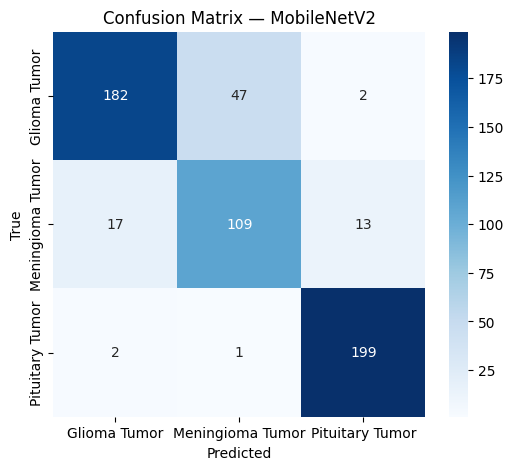

Fold: 3 block 4


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.7663 - loss: 0.2660
Epoch 1: val_accuracy improved from -inf to 0.84790, saving model to /kaggle/working/MobileNetV2_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 570ms/step - accuracy: 0.7666 - loss: 0.2657 - val_accuracy: 0.8479 - val_loss: 0.1383 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8100 - loss: 0.1804
Epoch 2: val_accuracy did not improve from 0.84790
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step - accuracy: 0.8102 - loss: 0.1803 - val_accuracy: 0.8462 - val_loss: 0.1386 - learning_rate: 1.0000e-05
Epoch 3/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8343 - loss: 0.1524
Epoch 3: val_accuracy improved from 0.84790 to 0.85490, saving model to /kaggle/working/MobileNetV2_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.8344 - loss: 0.1524 - val_accuracy: 0.8549 - val_loss: 0.1371 - learning_rate: 1.0000e-05
Epoch 4/5

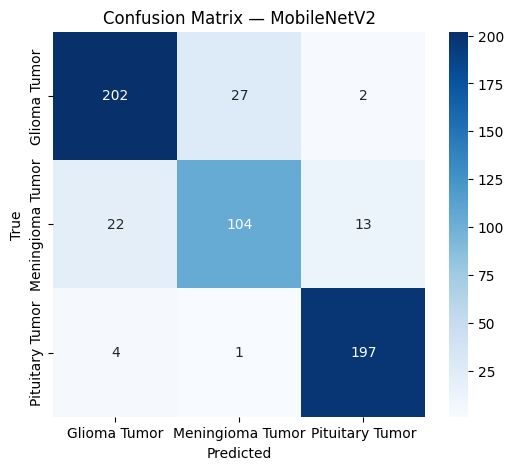

Fold: 3 block 3


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,632,203 (21.49 MB)

 Trainable params: 1,685,187 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,370,376 (12.86 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.8610 - loss: 0.1334
Epoch 1: val_accuracy improved from -inf to 0.86888, saving model to /kaggle/working/MobileNetV2_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 85s 723ms/step - accuracy: 0.8612 - loss: 0.1334 - val_accuracy: 0.8689 - val_loss: 0.1378 - learning_rate: 1.0000e-05
Epoch 2/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8698 - loss: 0.1067
Epoch 2: val_accuracy improved from 0.86888 to 0.87238, saving model to /kaggle/working/MobileNetV2_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.8702 - loss: 0.1065 - val_accuracy: 0.8724 - val_loss: 0.1447 - learning_rate: 1.0000e-05
Epoch 3/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8871 - loss: 0.0994
Epoch 3: val_accuracy did not improve from 0.87238
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.8872 - loss: 0.0994 - val_accuracy: 0.8619 - val_loss: 0.1565 - learning_rate: 1.0000e-05
Epoch 4/5

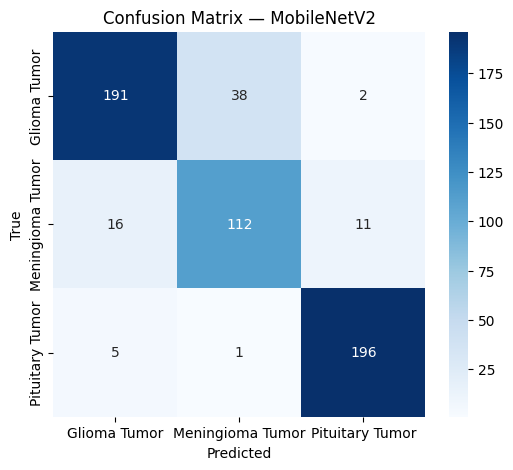

Fold: 3 block 2


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347,083 (24.21 MB)

 Trainable params: 2,042,627 (7.79 MB)

 Non-trainable params: 219,200 (856.25 KB)

 Optimizer params: 4,085,256 (15.58 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.8621 - loss: 0.1431
Epoch 1: val_accuracy improved from -inf to 0.86364, saving model to /kaggle/working/MobileNetV2_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 892ms/step - accuracy: 0.8622 - loss: 0.1430 - val_accuracy: 0.8636 - val_loss: 0.1555 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8875 - loss: 0.1050
Epoch 2: val_accuracy improved from 0.86364 to 0.86538, saving model to /kaggle/working/MobileNetV2_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step - accuracy: 0.8876 - loss: 0.1050 - val_accuracy: 0.8654 - val_loss: 0.1701 - learning_rate: 1.0000e-05
Epoch 3/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9006 - loss: 0.1038
Epoch 3: val_accuracy improved from 0.86538 to 0.87238, saving model to /kaggle/working/MobileNetV2_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step - accuracy: 0.9007 - loss: 0.1036 - val_ac

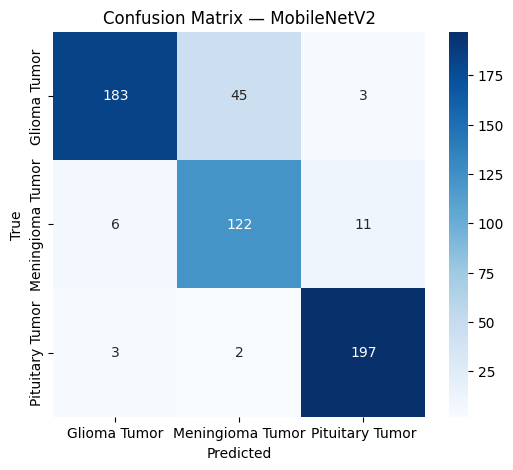

Fold: 3 block 1


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,635,979 (25.31 MB)

 Trainable params: 2,187,075 (8.34 MB)

 Non-trainable params: 74,752 (292.00 KB)

 Optimizer params: 4,374,152 (16.69 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8792 - loss: 0.1214
Epoch 1: val_accuracy improved from -inf to 0.87413, saving model to /kaggle/working/MobileNetV2_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8793 - loss: 0.1213 - val_accuracy: 0.8741 - val_loss: 0.1837 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9003 - loss: 0.1032
Epoch 2: val_accuracy improved from 0.87413 to 0.87937, saving model to /kaggle/working/MobileNetV2_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - accuracy: 0.9003 - loss: 0.1033 - val_accuracy: 0.8794 - val_loss: 0.1877 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8962 - loss: 0.0958
Epoch 3: val_accuracy did not improve from 0.87937
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8961 - loss: 0.0958 - val_accuracy: 0.8636 - val_loss: 0.2188 - learning_rate: 1.0000e-05
Epoch 4/50
80/

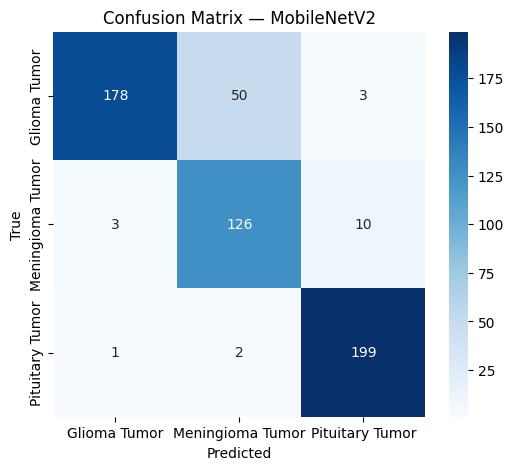

Fold: 4 block 5
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


/tmp/ipykernel_55/3387384670.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = applications.MobileNetV2(


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/50
76/78 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.5182 - loss: 0.6994
Epoch 1: val_accuracy improved from -inf to 0.79299, saving model to /kaggle/working/MobileNetV2_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 407ms/step - accuracy: 0.5221 - loss: 0.6906 - val_accuracy: 0.7930 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7653 - loss: 0.2401
Epoch 2: val_accuracy improved from 0.79299 to 0.80573, saving model to /kaggle/working/MobileNetV2_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.7654 - loss: 0.2399 - val_accuracy: 0.8057 - val_loss: 0.2052 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7989 - loss: 0.2061
Epoch 3: val_accuracy improved from 0.80573 to 0.82643, saving model to /kaggle/working/MobileNetV2_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.7989 - loss: 0.2059 - val_accuracy: 0

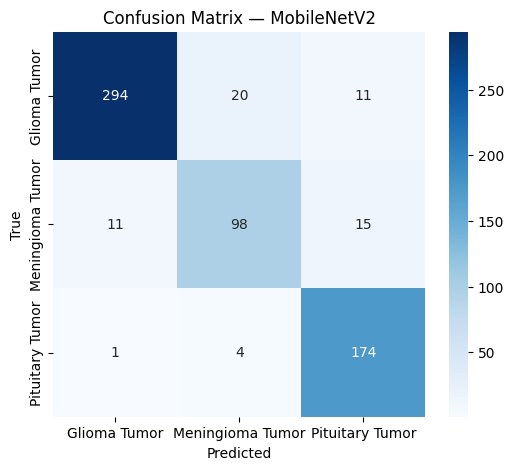

Fold: 4 block 4


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7082 - loss: 0.3158
Epoch 1: val_accuracy improved from -inf to 0.89331, saving model to /kaggle/working/MobileNetV2_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 65s 581ms/step - accuracy: 0.7085 - loss: 0.3153 - val_accuracy: 0.8933 - val_loss: 0.0856 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7766 - loss: 0.2211
Epoch 2: val_accuracy improved from 0.89331 to 0.90127, saving model to /kaggle/working/MobileNetV2_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - accuracy: 0.7768 - loss: 0.2209 - val_accuracy: 0.9013 - val_loss: 0.0853 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8085 - loss: 0.1929
Epoch 3: val_accuracy did not improve from 0.90127
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.8086 - loss: 0.1928 - val_accuracy: 0.8917 - val_loss: 0.0844 - learning_rate: 1.0000e-05
Epoch 4/5

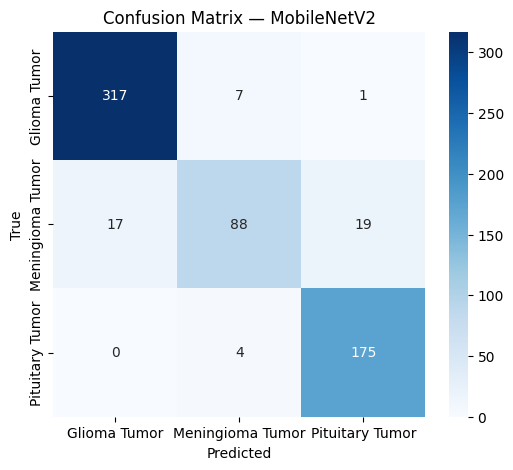

Fold: 4 block 3


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,632,203 (21.49 MB)

 Trainable params: 1,685,187 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,370,376 (12.86 MB)

None
Epoch 1/50
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8577 - loss: 0.1297
Epoch 1: val_accuracy improved from -inf to 0.93312, saving model to /kaggle/working/MobileNetV2_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 85s 739ms/step - accuracy: 0.8577 - loss: 0.1296 - val_accuracy: 0.9331 - val_loss: 0.0567 - learning_rate: 1.0000e-05
Epoch 2/50
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8779 - loss: 0.1212
Epoch 2: val_accuracy improved from 0.93312 to 0.93471, saving model to /kaggle/working/MobileNetV2_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.8782 - loss: 0.1209 - val_accuracy: 0.9347 - val_loss: 0.0516 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8917 - loss: 0.0981
Epoch 3: val_accuracy improved from 0.93471 to 0.93631, saving model to /kaggle/working/MobileNetV2_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.8917 - loss: 0.0982 - val_acc

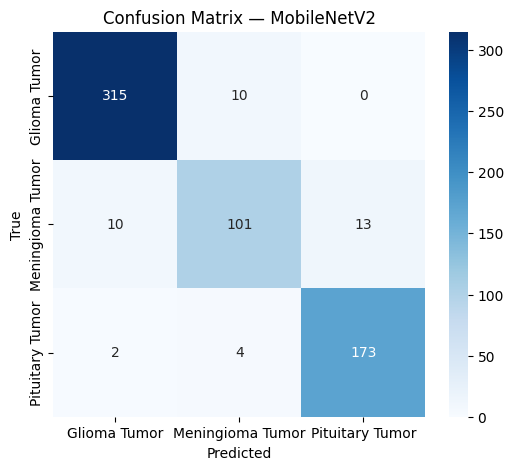

Fold: 4 block 2


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347,083 (24.21 MB)

 Trainable params: 2,042,627 (7.79 MB)

 Non-trainable params: 219,200 (856.25 KB)

 Optimizer params: 4,085,256 (15.58 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.8768 - loss: 0.1029
Epoch 1: val_accuracy improved from -inf to 0.93153, saving model to /kaggle/working/MobileNetV2_block_2_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 105s 906ms/step - accuracy: 0.8767 - loss: 0.1030 - val_accuracy: 0.9315 - val_loss: 0.0521 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9043 - loss: 0.0871
Epoch 2: val_accuracy did not improve from 0.93153
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.9042 - loss: 0.0871 - val_accuracy: 0.9315 - val_loss: 0.0555 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8929 - loss: 0.0927
Epoch 3: val_accuracy did not improve from 0.93153
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 143ms/step - accuracy: 0.8930 - loss: 0.0926 - val_accuracy: 0.9268 - val_loss: 0.0588 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8964 - loss:

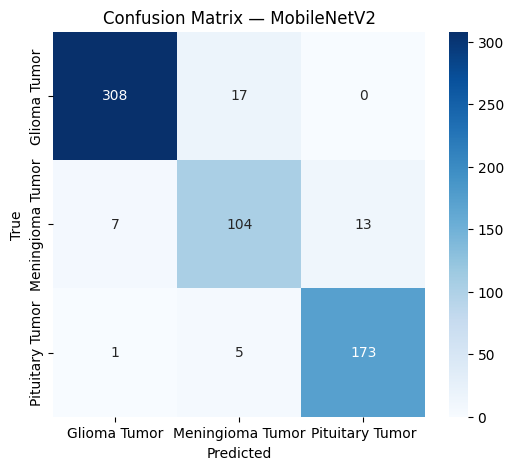

Fold: 4 block 1


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,635,979 (25.31 MB)

 Trainable params: 2,187,075 (8.34 MB)

 Non-trainable params: 74,752 (292.00 KB)

 Optimizer params: 4,374,152 (16.69 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8712 - loss: 0.1208   
Epoch 1: val_accuracy improved from -inf to 0.92516, saving model to /kaggle/working/MobileNetV2_block_1_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8713 - loss: 0.1208 - val_accuracy: 0.9252 - val_loss: 0.0559 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8828 - loss: 0.1106
Epoch 2: val_accuracy did not improve from 0.92516
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.8829 - loss: 0.1105 - val_accuracy: 0.9220 - val_loss: 0.0595 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9066 - loss: 0.0895
Epoch 3: val_accuracy did not improve from 0.92516
78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.9065 - loss: 0.0895 - val_accuracy: 0.9045 - val_loss: 0.0743 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8990 - loss: 0.

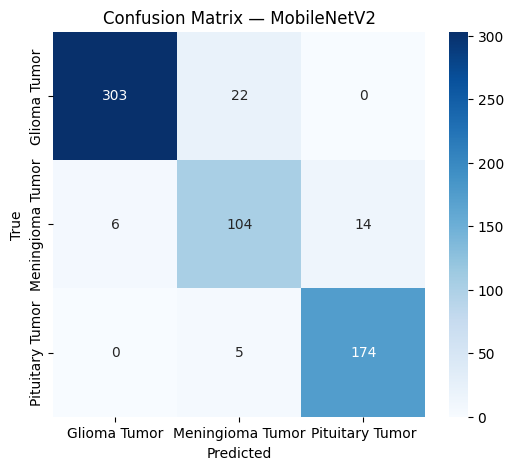

Fold: 5 block 5
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.


/tmp/ipykernel_55/3387384670.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = applications.MobileNetV2(


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/50
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5501 - loss: 0.5624
Epoch 1: val_accuracy improved from -inf to 0.71695, saving model to /kaggle/working/MobileNetV2_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 413ms/step - accuracy: 0.5529 - loss: 0.5584 - val_accuracy: 0.7170 - val_loss: 0.3453 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7874 - loss: 0.2185
Epoch 2: val_accuracy improved from 0.71695 to 0.75428, saving model to /kaggle/working/MobileNetV2_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.7873 - loss: 0.2185 - val_accuracy: 0.7543 - val_loss: 0.3212 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8136 - loss: 0.1711
Epoch 3: val_accuracy improved from 0.75428 to 0.76050, saving model to /kaggle/working/MobileNetV2_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.8139 - loss: 0.1709 - val_accuracy: 0

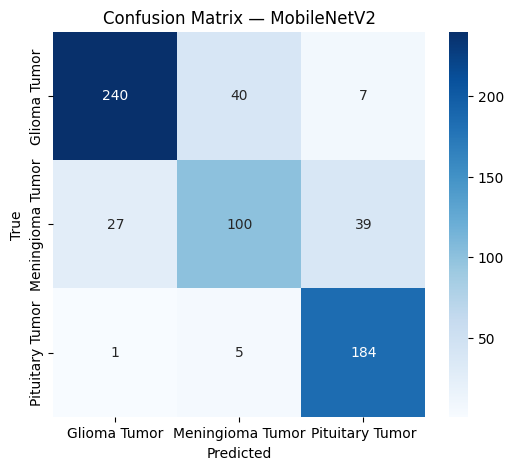

Fold: 5 block 4


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,515 (8.66 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 7,688 (30.04 KB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7478 - loss: 0.3101
Epoch 1: val_accuracy improved from -inf to 0.79316, saving model to /kaggle/working/MobileNetV2_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 65s 593ms/step - accuracy: 0.7482 - loss: 0.3095 - val_accuracy: 0.7932 - val_loss: 0.2332 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8187 - loss: 0.2006
Epoch 2: val_accuracy improved from 0.79316 to 0.79627, saving model to /kaggle/working/MobileNetV2_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.8188 - loss: 0.2004 - val_accuracy: 0.7963 - val_loss: 0.2527 - learning_rate: 1.0000e-05
Epoch 3/50
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8434 - loss: 0.1646
Epoch 3: val_accuracy improved from 0.79627 to 0.79782, saving model to /kaggle/working/MobileNetV2_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - accuracy: 0.8436 - loss: 0.1642 - val_acc

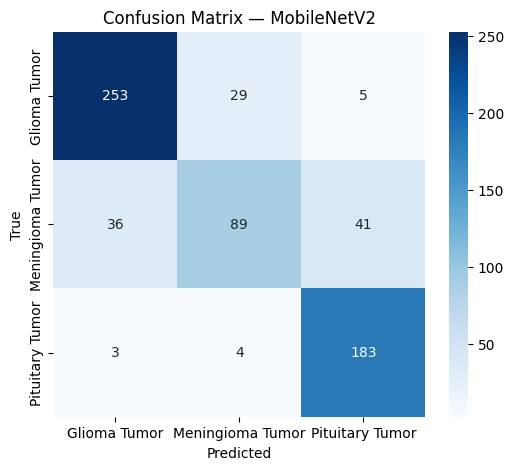

Fold: 5 block 3


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,632,203 (21.49 MB)

 Trainable params: 1,685,187 (6.43 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 3,370,376 (12.86 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.8361 - loss: 0.1599
Epoch 1: val_accuracy improved from -inf to 0.81337, saving model to /kaggle/working/MobileNetV2_block_3_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 85s 758ms/step - accuracy: 0.8362 - loss: 0.1598 - val_accuracy: 0.8134 - val_loss: 0.2670 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8871 - loss: 0.1146
Epoch 2: val_accuracy did not improve from 0.81337
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.8869 - loss: 0.1147 - val_accuracy: 0.8103 - val_loss: 0.2840 - learning_rate: 1.0000e-05
Epoch 3/50
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8734 - loss: 0.1210
Epoch 3: val_accuracy did not improve from 0.81337
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - accuracy: 0.8737 - loss: 0.1208 - val_accuracy: 0.8118 - val_loss: 0.2834 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8858 - loss: 

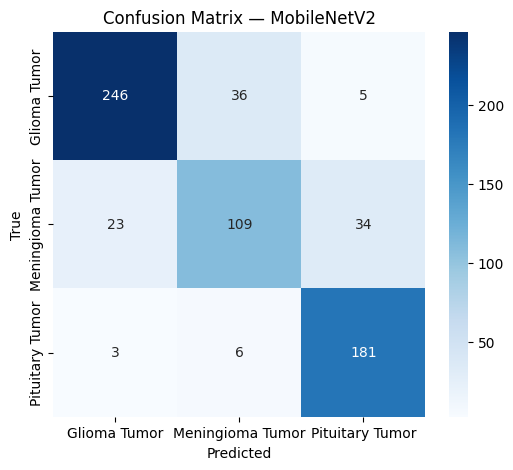

Fold: 5 block 2


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347,083 (24.21 MB)

 Trainable params: 2,042,627 (7.79 MB)

 Non-trainable params: 219,200 (856.25 KB)

 Optimizer params: 4,085,256 (15.58 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.8872 - loss: 0.1186
Epoch 1: val_accuracy improved from -inf to 0.84137, saving model to /kaggle/working/MobileNetV2_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 105s 929ms/step - accuracy: 0.8871 - loss: 0.1186 - val_accuracy: 0.8414 - val_loss: 0.2687 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8928 - loss: 0.0970
Epoch 2: val_accuracy did not improve from 0.84137
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - accuracy: 0.8928 - loss: 0.0971 - val_accuracy: 0.8351 - val_loss: 0.2930 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8935 - loss: 0.0865
Epoch 3: val_accuracy did not improve from 0.84137
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.8936 - loss: 0.0865 - val_accuracy: 0.8320 - val_loss: 0.3182 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8931 - loss:

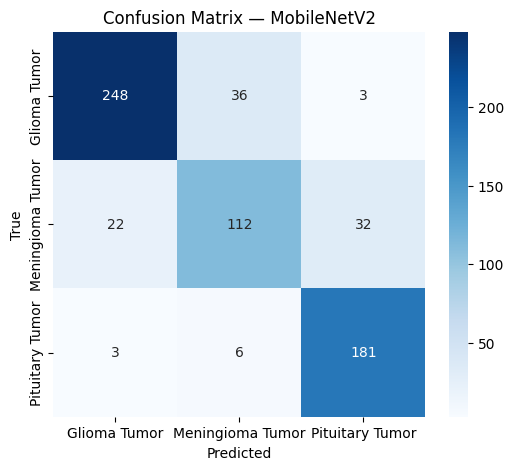

Fold: 5 block 1


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,635,979 (25.31 MB)

 Trainable params: 2,187,075 (8.34 MB)

 Non-trainable params: 74,752 (292.00 KB)

 Optimizer params: 4,374,152 (16.69 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8888 - loss: 0.1002
Epoch 1: val_accuracy improved from -inf to 0.83670, saving model to /kaggle/working/MobileNetV2_block_1_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8888 - loss: 0.1003 - val_accuracy: 0.8367 - val_loss: 0.2822 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8922 - loss: 0.1079
Epoch 2: val_accuracy did not improve from 0.83670
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.8923 - loss: 0.1078 - val_accuracy: 0.8367 - val_loss: 0.2762 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8985 - loss: 0.0973
Epoch 3: val_accuracy did not improve from 0.83670
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.8985 - loss: 0.0972 - val_accuracy: 0.8367 - val_loss: 0.2775 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9187 - loss: 0.071

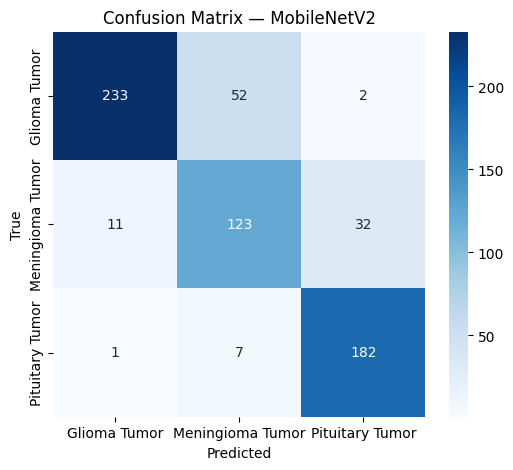

In [18]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 5')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b5.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(4, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.9169741868972778,
  0.8335787653923035,
  0.8566433787345886,
  0.9012739062309265,
  0.8149300217628479],
 [0.9354243278503418,
  0.8291605114936829,
  0.8793706297874451,
  0.9235668778419495,
  0.8164852261543274],
 [0.9354243278503418,
  0.8365243077278137,
  0.8723776340484619,
  0.9378980994224548,
  0.8335925340652466],
 [0.946494460105896,
  0.8748158812522888,
  0.8776223659515381,
  0.9315286874771118,
  0.841368556022644],
 [0.9261992573738098,
  0.8674521446228027,
  0.8793706297874451,
  0.925159215927124,
  0.8367029428482056]]

In [20]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {5 - _} - block 5: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 5 - block 5: 86.47%
Accuracy unfreeze block 4 - block 5: 87.68%
Accuracy unfreeze block 3 - block 5: 88.32%
Accuracy unfreeze block 2 - block 5: 89.44%
Accuracy unfreeze block 1 - block 5: 88.70%
